# Principal Component Analysis (PCA)

# Introduction, Standardization & Covariance Matrix

---

# What is PCA?

Principal Component Analysis (PCA) is an **Unsupervised Machine Learning** algorithm used for **Dimensionality Reduction**.

It converts a dataset with many features into a smaller set of new features (called **Principal Components**) while preserving as much information (variance) as possible.

---

# Why PCA?

Suppose you have a student dataset.

| Height | Weight | Age | Marks | Attendance |
|---------|--------|-----|--------|------------|
|170|65|20|85|90|
|172|67|21|88|91|
|168|63|20|84|89|

Some features are highly correlated.

Instead of using all 5 features, PCA may reduce them to **2 Principal Components** with very little information loss.

Benefits:

- Reduce dimensions
- Faster model training
- Remove redundant features
- Reduce overfitting
- Better visualization

---

# Real-Life Example

Imagine a library with **100 books**.

Instead of carrying all 100 books, you create **10 summary books** that contain the most important information.

PCA works similarly.

```
100 Features
      │
      ▼
Remove Redundant Information
      │
      ▼
10 Principal Components
```

---

# What is Dimensionality?

Dimension = Number of Features.

Example:

| House Area | Bedrooms | Age | Price |
|------------|----------|-----|-------|

Number of Features = **3**

Therefore,

```
Dimension = 3
```

---

# Curse of Dimensionality

As the number of features increases:

- Training becomes slower.
- Memory usage increases.
- Distance calculations become unreliable.
- Overfitting becomes more likely.

PCA solves this by reducing dimensions.

---

# PCA Workflow

```
Original Dataset
      │
      ▼
Standardization
      │
      ▼
Covariance Matrix
      │
      ▼
Eigenvalues
      │
      ▼
Eigenvectors
      │
      ▼
Principal Components
      │
      ▼
Reduced Dataset
```

---

# Step 1: Standardization

PCA is sensitive to feature scales.

Example:

| Salary | Age |
|---------|-----|
|500000|25|
|600000|30|
|700000|35|

Salary is much larger than Age.

Without standardization, Salary dominates PCA.

---

# Z-Score Standardization

Formula

\[
Z=\frac{X-\mu}{\sigma}
\]

Where:

- X = Value
- μ = Mean
- σ = Standard Deviation

---

# Example

Dataset

```
10

20

30
```

---

## Mean

Formula

\[
Mean=\frac{\sum X}{N}
\]

Calculation

\[
\frac{10+20+30}{3}
=
20
\]

Mean

```
20
```

---

## Standard Deviation

Formula

\[
\sigma=\sqrt{\frac{\sum (X-\mu)^2}{N}}
\]

Step 1

| X | X-Mean | Square |
|---|--------|---------|
|10|-10|100|
|20|0|0|
|30|10|100|

Sum

```
200
```

Variance

\[
200/3
=
66.67
\]

Standard Deviation

\[
\sqrt{66.67}
=
8.16
\]

---

# Standardized Values

For

```
10
```

\[
\frac{10-20}{8.16}
=
-1.22
\]

For

```
20
```

\[
0
\]

For

```
30
```

\[
1.22
\]

Final Standardized Dataset

| Original | Standardized |
|----------|--------------|
|10|-1.22|
|20|0|
|30|1.22|

---

# Step 2: Covariance

Covariance measures whether two variables move together.

Positive Covariance

```
Height ↑

Weight ↑
```

Negative Covariance

```
Speed ↑

Travel Time ↓
```

Zero Covariance

No relationship.

---

# Covariance Formula

\[
Cov(X,Y)=\frac{\sum (X-\bar X)(Y-\bar Y)}{N-1}
\]

---

# Example

Height

```
160
170
180
```

Weight

```
55
65
75
```

Mean Height

```
170
```

Mean Weight

```
65
```

---

|Height|H-Mean|Weight|W-Mean|Multiply|
|------|------|------|------|--------|
|160|-10|55|-10|100|
|170|0|65|0|0|
|180|10|75|10|100|

Sum

```
200
```

Covariance

\[
200/(3-1)
=
100
\]

Positive covariance means Height and Weight increase together.

---

# Covariance Matrix

Suppose two features:

Height

Weight

Covariance Matrix

\[
\begin{bmatrix}
Cov(H,H) & Cov(H,W)\\
Cov(W,H) & Cov(W,W)
\end{bmatrix}
\]

Example

\[
\begin{bmatrix}
100 & 80\\
80 & 120
\end{bmatrix}
\]

Diagonal values = Variance.

Off-diagonal values = Covariance.

---

# Why Covariance Matrix?

The covariance matrix tells PCA:

- Which features are related?
- Which features contain similar information?
- Which directions have the highest variance?

This matrix is the input for the next step:
PCA Decision Rule
Largest Eigenvalue → Principal Component 1 (PC1) (maximum variance)
Second Largest Eigenvalue → PC2
Third Largest → PC3
➡️ **Eigenvalues & Eigenvectors**

---

# Summary

```
Raw Dataset
      │
      ▼
Calculate Mean
      │
      ▼
Calculate Standard Deviation
      │
      ▼
Standardize Data (Z-Score)
      │
      ▼
Calculate Covariance
      │
      ▼
Create Covariance Matrix ([
C=\frac{1}{n-1}X^TX
\)
      │
      ▼
Ready for Eigenvalues & Eigenvectors
```

---

# Interview Questions

### Why is Standardization important in PCA?

Because PCA is based on variance. Features with larger scales can dominate the principal components if the data is not standardized.

---

### What is Covariance?

Covariance measures how two variables change together. A positive value means they increase together, while a negative value means one increases as the other decreases.

---

### Why do we calculate the Covariance Matrix?

Because PCA uses the covariance matrix to identify the directions (principal components) with the maximum variance.

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import warnings
warnings.filterwarnings("ignore")
df=pd.read_csv("/content/data.csv")
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


        PC1       PC2
0 -1.993474 -3.082643
1 -0.328516 -1.210345
2 -0.859903 -2.907035
3 -1.055298 -0.121192
4 -1.830330 -4.205696
Explained Variance Ratio
[0.25212342 0.13517441]


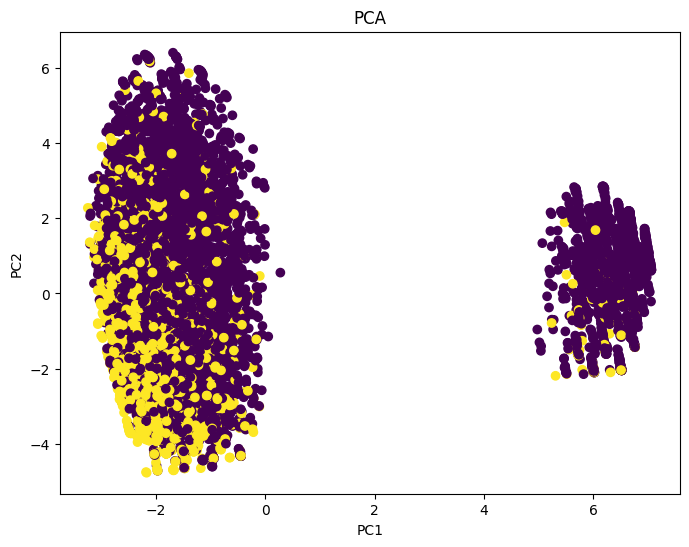

In [ ]:
df["TotalCharges"]=pd.to_numeric(df["TotalCharges"],errors="coerce")

df.dropna(inplace=True)

df.drop("customerID",axis=1,inplace=True)

y=df["Churn"].apply(lambda x: 1 if x=="Yes" else 0)

X = df.drop(["Churn"],axis=1)
X=pd.get_dummies(X,columns=["gender","Partner","Dependents","PhoneService","MultipleLines","InternetService","OnlineSecurity","OnlineBackup","DeviceProtection","TechSupport","StreamingTV","StreamingMovies","Contract","PaperlessBilling","PaymentMethod"])

# Standardization
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)


pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled)


df = pd.DataFrame(
    X_pca,
    columns=["PC1","PC2"]
)

print(df.head())


print("Explained Variance Ratio")
print(pca.explained_variance_ratio_)


plt.figure(figsize=(8,6))

plt.scatter(
    X_pca[:,0],
    X_pca[:,1],
    c=y
)

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA")

plt.show()